<a href="https://colab.research.google.com/github/harshitha3506/deeplearning/blob/main/DL_DATASET_EXPLORATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPLORING DATASET FOR DEEP LEARNING MODEL

by **HARSHITHA PALADUGU** 160123737157

In [ ]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


ABOUT THE DATASET **CIFAR10** :
CIFAR-10 was derived from the larger Tiny Images dataset, curated to provide a standardized subset for machine learning research.CIFAR-10 is a widely used dataset containing 60,000 32×32 color images across 10 classes. It is used to demonstrate deep learning techniques such as neural networks, CNNs, optimization, and regularization

Load + Preprocess

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
# Flatten for MLP
X_train_flat = X_train.reshape(50000, -1)
X_test_flat = X_test.reshape(10000, -1)
# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

MLP model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(512, activation='relu', input_shape=(3072,)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flat, y_train, epochs=5, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3322 - loss: 1.8766 - val_accuracy: 0.3378 - val_loss: 1.8064
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3997 - loss: 1.6940 - val_accuracy: 0.3764 - val_loss: 1.7553
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4285 - loss: 1.6199 - val_accuracy: 0.4216 - val_loss: 1.6356
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4462 - loss: 1.5659 - val_accuracy: 0.4331 - val_loss: 1.6082
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4619 - loss: 1.5202 - val_accuracy: 0.4473 - val_loss: 1.5792






1.  WE NOW USE ML MODEL TO UNDERTSAND THE DATASET AND MODELS BUT IT FLATTENS ALL IMAGES IMPLIES LOOSES SPATIAL INFO EDGES ETC
2. MLP gave low accuracy because it cannot capture spatial relationships in image data





Nearby pixels are** related**,Patterns like **edges**, **textures** exist
##CNN uses filters/kernels to scan image
It learns:
edges
corners
textures
objects






In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential()
# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))
# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))
# Flatten
model.add(Flatten())
# Fully Connected Layer
model.add(Dense(64, activation='relu'))
# Output Layer
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train, y_train,
                    epochs=5,
                    validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 39ms/step - accuracy: 0.4742 - loss: 1.4660 - val_accuracy: 0.5790 - val_loss: 1.1895
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.6106 - loss: 1.1085 - val_accuracy: 0.6230 - val_loss: 1.0888
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.6550 - loss: 0.9858 - val_accuracy: 0.6437 - val_loss: 1.0175
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 38ms/step - accuracy: 0.6853 - loss: 0.8959 - val_accuracy: 0.6574 - val_loss: 0.9889
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 48s 39ms/step - accuracy: 0.7110 - loss: 0.8281 - val_accuracy: 0.6714 - val_loss: 0.9416


Convolution Layer
1.   Learns features using filters
2.   Detects edges, patterns

Pooling Layer
1.   Reduces size
2.   Keeps important features

Flatten
1.   Converts 2D → 1D for classification








##OBSERVATIONS:
1.   The CNN model achieved significantly higher accuracy compared to MLP
2.   Unlike MLP, CNN preserves spatial relationships and learns meaningful features such as edges and textures.
3.   CNN uses fewer parameters due to parameter sharing, making it more efficient and less prone to overfitting compared to fully connected networks




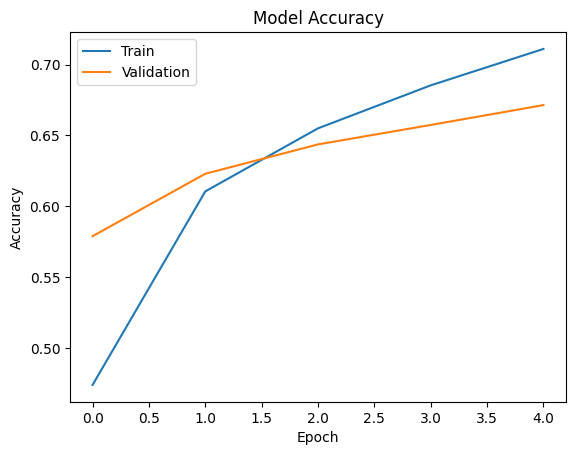

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

###The training and validation accuracy curves show that CNN learns effectively and generalizes better than MLP

1. varying the number of filters while keeping other parameters constant, in order to analyze its impact on performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Case 1: 32 Filters

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history1 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.4398 - loss: 1.5584 - val_accuracy: 0.5336 - val_loss: 1.2985
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.5699 - loss: 1.2113 - val_accuracy: 0.5801 - val_loss: 1.1989
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.6218 - loss: 1.0759 - val_accuracy: 0.6342 - val_loss: 1.0525
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.6553 - loss: 0.9948 - val_accuracy: 0.6394 - val_loss: 1.0337
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.6751 - loss: 0.9333 - val_accuracy: 0.6489 - val_loss: 1.0058


Case 2: 64 Filters

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history2 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.4595 - loss: 1.4919 - val_accuracy: 0.5459 - val_loss: 1.2826
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.5972 - loss: 1.1430 - val_accuracy: 0.6123 - val_loss: 1.1099
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 68ms/step - accuracy: 0.6486 - loss: 1.0028 - val_accuracy: 0.6524 - val_loss: 1.0049
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6815 - loss: 0.9105 - val_accuracy: 0.6544 - val_loss: 1.0111
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 68ms/step - accuracy: 0.7083 - loss: 0.8386 - val_accuracy: 0.6613 - val_loss: 0.9881


Case 3: 128 Filters

In [ ]:
model = Sequential([
    Conv2D(128, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history3 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 158ms/step - accuracy: 0.4514 - loss: 1.5055 - val_accuracy: 0.5693 - val_loss: 1.2241
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 206s 165ms/step - accuracy: 0.6006 - loss: 1.1343 - val_accuracy: 0.6166 - val_loss: 1.0868
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 205s 164ms/step - accuracy: 0.6578 - loss: 0.9822 - val_accuracy: 0.6247 - val_loss: 1.0690
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 163ms/step - accuracy: 0.6919 - loss: 0.8867 - val_accuracy: 0.6715 - val_loss: 0.9594
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 193s 155ms/step - accuracy: 0.7183 - loss: 0.8111 - val_accuracy: 0.6811 - val_loss: 0.9510


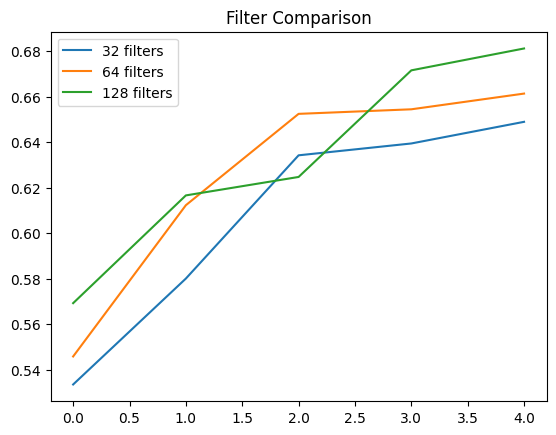

In [ ]:
plt.plot(history1.history['val_accuracy'], label='32 filters')
plt.plot(history2.history['val_accuracy'], label='64 filters')
plt.plot(history3.history['val_accuracy'], label='128 filters')

plt.legend()
plt.title("Filter Comparison")
plt.show()


32	Basic features (edges)
64	More patterns (shapes)
128	Complex features (objects)

### **OVERFITTING ANALYSIS**

After increasing filters:

Model becomes more powerful
So risk of overfitting increases




To address overfitting, we applied regularization techniques.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_base = model.fit(X_train, y_train, epochs=5, validation_split=0.2)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 74ms/step - accuracy: 0.4678 - loss: 1.4737 - val_accuracy: 0.5735 - val_loss: 1.2350
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.6085 - loss: 1.1139 - val_accuracy: 0.6248 - val_loss: 1.0761
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.6586 - loss: 0.9822 - val_accuracy: 0.6560 - val_loss: 0.9921
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 73ms/step - accuracy: 0.6903 - loss: 0.8970 - val_accuracy: 0.6800 - val_loss: 0.9387
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - accuracy: 0.7160 - loss: 0.8170 - val_accuracy: 0.6739 - val_loss: 0.9553


#increase filters

In [ ]:
model = Sequential([
    Conv2D(128, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_filters = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 161ms/step - accuracy: 0.4421 - loss: 1.5402 - val_accuracy: 0.5584 - val_loss: 1.2540
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 212s 169ms/step - accuracy: 0.5914 - loss: 1.1580 - val_accuracy: 0.5966 - val_loss: 1.1743
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 263s 170ms/step - accuracy: 0.6460 - loss: 1.0121 - val_accuracy: 0.6290 - val_loss: 1.0639
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 160ms/step - accuracy: 0.6792 - loss: 0.9157 - val_accuracy: 0.6672 - val_loss: 0.9584
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 200s 158ms/step - accuracy: 0.7065 - loss: 0.8454 - val_accuracy: 0.6643 - val_loss: 0.9821


APPLYING L2 REGULARIZATION : Adds penalty for large weights,Keeps model simple

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_l2 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 73ms/step - accuracy: 0.4348 - loss: 1.6349 - val_accuracy: 0.5124 - val_loss: 1.4449
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 68ms/step - accuracy: 0.5591 - loss: 1.3516 - val_accuracy: 0.5667 - val_loss: 1.3447
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 67ms/step - accuracy: 0.6042 - loss: 1.2497 - val_accuracy: 0.6106 - val_loss: 1.2417
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 148s 72ms/step - accuracy: 0.6317 - loss: 1.1929 - val_accuracy: 0.6078 - val_loss: 1.2598
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 136s 67ms/step - accuracy: 0.6504 - loss: 1.1488 - val_accuracy: 0.6355 - val_loss: 1.1903


Overfitting reduced slightly, but still present

EARLY STOPPING : Stops training when validation stops improving

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

history_es = model.fit(X_train, y_train,
                       epochs=20,
                       validation_split=0.2,
                       callbacks=[early_stop])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.6638 - loss: 1.1170 - val_accuracy: 0.6406 - val_loss: 1.2146
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 67ms/step - accuracy: 0.6760 - loss: 1.0917 - val_accuracy: 0.6662 - val_loss: 1.1422
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - accuracy: 0.6830 - loss: 1.0679 - val_accuracy: 0.6634 - val_loss: 1.1384
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 72ms/step - accuracy: 0.6937 - loss: 1.0460 - val_accuracy: 0.6688 - val_loss: 1.1249
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - accuracy: 0.7014 - loss: 1.0302 - val_accuracy: 0.6629 - val_loss: 1.1342
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.7110 - loss: 1.0055 - val_accuracy: 0.6760 - val_loss: 1.1116
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step - accuracy: 0.7196 - loss: 0.9900 - val_accuracy: 0.6673 - val_loss: 1.1550
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.7206

Stops over-training, but does not fully solve overfitting

DATA AUGMENTATION:Creates more training data by:
1.   flipping
2.   rotating
3.   shifting
#####increases data diversity



In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    horizontal_flip=True
)

history_aug = model.fit(datagen.flow(X_train, y_train, batch_size=64),
                        epochs=5,
                        validation_data=(X_test, y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 157ms/step - accuracy: 0.7105 - loss: 1.0210 - val_accuracy: 0.7114 - val_loss: 1.0290
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 153ms/step - accuracy: 0.7145 - loss: 0.9958 - val_accuracy: 0.7012 - val_loss: 1.0608
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 153ms/step - accuracy: 0.7149 - loss: 0.9909 - val_accuracy: 0.7066 - val_loss: 1.0291
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 155ms/step - accuracy: 0.7165 - loss: 0.9790 - val_accuracy: 0.7124 - val_loss: 0.9994
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 152ms/step - accuracy: 0.7190 - loss: 0.9743 - val_accuracy: 0.7146 - val_loss: 0.9884


Better generalization, but training becomes slower

DROPOUT:Randomly turns OFF neurons during training,Prevents neurons from depending on each other

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_dropout = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 67ms/step - accuracy: 0.3578 - loss: 1.7389 - val_accuracy: 0.5176 - val_loss: 1.3636
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 0.4818 - loss: 1.4328 - val_accuracy: 0.5421 - val_loss: 1.3010
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 67ms/step - accuracy: 0.5232 - loss: 1.3267 - val_accuracy: 0.5897 - val_loss: 1.1745
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 66ms/step - accuracy: 0.5538 - loss: 1.2530 - val_accuracy: 0.6034 - val_loss: 1.1252
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.5765 - loss: 1.1854 - val_accuracy: 0.6432 - val_loss: 1.0343


COMPARISION GRAPH

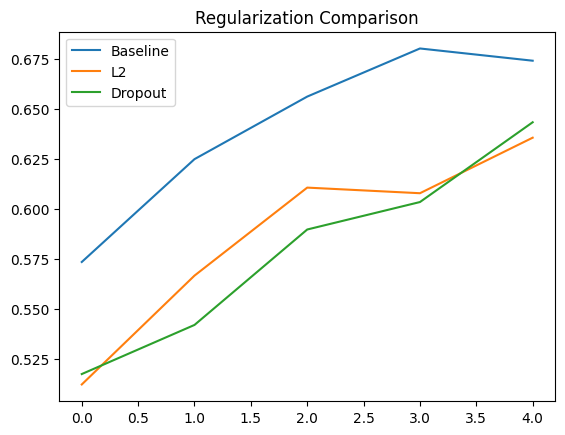

In [ ]:
plt.plot(history_base.history['val_accuracy'], label='Baseline')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')

plt.legend()
plt.title("Regularization Comparison")
plt.show()

##OBSERVATION


* Among all techniques, dropout provided the best balance between reducing overfitting and maintaining model performance. It randomly disables neurons, forcing the model to learn more robust features.
* While L2 regularization and early stopping helped reduce overfitting to some extent, dropout proved to be the most effective technique. Data augmentation improved generalization but increased training complexity. Therefore, dropout was selected as the best regularization method for this model
* Dropout prevents co-adaptation of neurons by randomly disabling them, making the model more robust and reducing overfitting effectively



#OPTIMIZATION & PERFORMANCE IMPROVEMENT

WE DEALT WITH OVERFITTIG NOW WE WILL TRY TO IMPROVE TRAINING

base model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_model():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])
    return model

In [ ]:

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


SGD

In [ ]:
model = create_model()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_sgd = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 103s 82ms/step - accuracy: 0.2021 - loss: 2.1626 - val_accuracy: 0.3041 - val_loss: 1.9715
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 104s 83ms/step - accuracy: 0.2979 - loss: 1.9253 - val_accuracy: 0.3921 - val_loss: 1.7371
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.3611 - loss: 1.7462 - val_accuracy: 0.4514 - val_loss: 1.5609
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 84ms/step - accuracy: 0.4077 - loss: 1.6298 - val_accuracy: 0.4741 - val_loss: 1.4872
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 80ms/step - accuracy: 0.4367 - loss: 1.5557 - val_accuracy: 0.4960 - val_loss: 1.4253


Slow convergence, lower accuracy

SGD + MOMENTUM

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_momentum = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 87ms/step - accuracy: 0.4409 - loss: 1.5506 - val_accuracy: 0.5521 - val_loss: 1.2864
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.5145 - loss: 1.3617 - val_accuracy: 0.5762 - val_loss: 1.1915
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 82ms/step - accuracy: 0.5510 - loss: 1.2597 - val_accuracy: 0.6099 - val_loss: 1.1004
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.5782 - loss: 1.1942 - val_accuracy: 0.6145 - val_loss: 1.1130
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 75ms/step - accuracy: 0.5990 - loss: 1.1425 - val_accuracy: 0.6294 - val_loss: 1.0426


Faster than SGD, smoother updates

NESTEROV

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_nesterov = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 83ms/step - accuracy: 0.5124 - loss: 1.3554 - val_accuracy: 0.5826 - val_loss: 1.1853
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.5302 - loss: 1.3014 - val_accuracy: 0.6151 - val_loss: 1.1055
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 80ms/step - accuracy: 0.5417 - loss: 1.2672 - val_accuracy: 0.5938 - val_loss: 1.1450
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 99s 79ms/step - accuracy: 0.5494 - loss: 1.2406 - val_accuracy: 0.5988 - val_loss: 1.1056
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 100s 80ms/step - accuracy: 0.5559 - loss: 1.2235 - val_accuracy: 0.6136 - val_loss: 1.0844


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Better convergence than momentum

ADAGRAD

In [ ]:
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adagrad',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_adagrad = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 91s 72ms/step - accuracy: 0.1505 - loss: 2.2597 - val_accuracy: 0.2090 - val_loss: 2.1942
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 74ms/step - accuracy: 0.2031 - loss: 2.1522 - val_accuracy: 0.2665 - val_loss: 2.0777
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 76ms/step - accuracy: 0.2313 - loss: 2.0782 - val_accuracy: 0.2905 - val_loss: 2.0102
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 72ms/step - accuracy: 0.2509 - loss: 2.0347 - val_accuracy: 0.3088 - val_loss: 1.9653
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 72ms/step - accuracy: 0.2686 - loss: 2.0001 - val_accuracy: 0.3265 - val_loss: 1.9225


Learning slows down over time

RMSPROP

In [ ]:
model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_rmsprop = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 94s 75ms/step - accuracy: 0.3590 - loss: 1.7606 - val_accuracy: 0.5056 - val_loss: 1.4019
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 139s 72ms/step - accuracy: 0.5061 - loss: 1.3963 - val_accuracy: 0.5743 - val_loss: 1.2045
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - accuracy: 0.5627 - loss: 1.2542 - val_accuracy: 0.6186 - val_loss: 1.1107
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 72ms/step - accuracy: 0.5870 - loss: 1.1958 - val_accuracy: 0.6323 - val_loss: 1.0838
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 90s 72ms/step - accuracy: 0.6041 - loss: 1.1676 - val_accuracy: 0.6301 - val_loss: 1.1053


Stable and good performance

ADAM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(32,32,3)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_adam = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 98s 77ms/step - accuracy: 0.3595 - loss: 1.7296 - val_accuracy: 0.4928 - val_loss: 1.4479
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 92s 74ms/step - accuracy: 0.4811 - loss: 1.4363 - val_accuracy: 0.5655 - val_loss: 1.2299
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 75ms/step - accuracy: 0.5271 - loss: 1.3177 - val_accuracy: 0.5906 - val_loss: 1.1554
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 89s 71ms/step - accuracy: 0.5626 - loss: 1.2346 - val_accuracy: 0.6231 - val_loss: 1.0750
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 74ms/step - accuracy: 0.5818 - loss: 1.1805 - val_accuracy: 0.6400 - val_loss: 1.0283


Best performance, fastest convergence

###OBSERVATION :
Among all optimization techniques, Adam provided the best performance due to adaptive learning rates and faster convergence. SGD showed slower learning, while momentum-based methods improved convergence stability

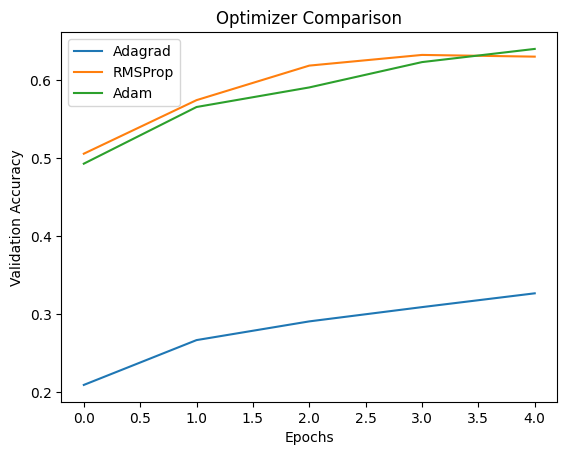

In [ ]:
import matplotlib.pyplot as plt

if 'history_sgd' in globals():
    plt.plot(history_sgd.history['val_accuracy'], label='SGD')

if 'history_momentum' in globals():
    plt.plot(history_momentum.history['val_accuracy'], label='Momentum')

if 'history_nesterov' in globals():
    plt.plot(history_nesterov.history['val_accuracy'], label='Nesterov')

if 'history_adagrad' in globals():
    plt.plot(history_adagrad.history['val_accuracy'], label='Adagrad')

if 'history_rmsprop' in globals():
    plt.plot(history_rmsprop.history['val_accuracy'], label='RMSProp')

if 'history_adam' in globals():
    plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.legend()
plt.title("Optimizer Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()

BUILDING OPTIMIZED FINAL MODEL


In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_final = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 111s 87ms/step - accuracy: 0.3390 - loss: 1.7874 - val_accuracy: 0.4834 - val_loss: 1.4706
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 106s 84ms/step - accuracy: 0.4400 - loss: 1.5301 - val_accuracy: 0.4908 - val_loss: 1.4424
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 85ms/step - accuracy: 0.4838 - loss: 1.4228 - val_accuracy: 0.5359 - val_loss: 1.3030
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 108s 86ms/step - accuracy: 0.5132 - loss: 1.3464 - val_accuracy: 0.5607 - val_loss: 1.2493
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 85ms/step - accuracy: 0.5390 - loss: 1.2822 - val_accuracy: 0.6024 - val_loss: 1.1171


FINAL EVAL

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6288 - loss: 1.0763


[1.0762566328048706, 0.6287999749183655]

graphical rep

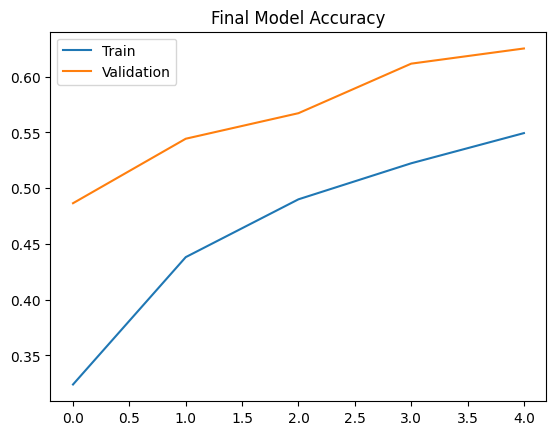

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_final.history['accuracy'])
plt.plot(history_final.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title("Final Model Accuracy")
plt.show()

Pooling is used to reduce image size while keeping important features.

MODEL 1: MAX **POOLING**

In [ ]:
from tensorflow.keras.layers import AveragePooling2D

model_max = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model_max.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_max = model_max.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.4537 - loss: 1.5106 - val_accuracy: 0.5368 - val_loss: 1.3051
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.6013 - loss: 1.1372 - val_accuracy: 0.6119 - val_loss: 1.1031
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 44ms/step - accuracy: 0.6488 - loss: 1.0054 - val_accuracy: 0.6398 - val_loss: 1.0270
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.6790 - loss: 0.9252 - val_accuracy: 0.6700 - val_loss: 0.9486
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 43ms/step - accuracy: 0.7041 - loss: 0.8562 - val_accuracy: 0.6623 - val_loss: 0.9688


MODEL 2: AVERAGE POOLING

In [ ]:
model_avg = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    AveragePooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    AveragePooling2D((2,2)),

    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model_avg.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_avg = model_avg.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 37ms/step - accuracy: 0.4322 - loss: 1.5737 - val_accuracy: 0.5029 - val_loss: 1.3887
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 37ms/step - accuracy: 0.5534 - loss: 1.2571 - val_accuracy: 0.5870 - val_loss: 1.1690
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.6123 - loss: 1.1041 - val_accuracy: 0.6221 - val_loss: 1.0805
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.6479 - loss: 1.0066 - val_accuracy: 0.6362 - val_loss: 1.0374
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.6771 - loss: 0.9330 - val_accuracy: 0.6424 - val_loss: 1.0217


COMPARISION

In [ ]:
print("MaxPooling:", history_max.history['val_accuracy'][-1])
print("AveragePooling:", history_avg.history['val_accuracy'][-1])

MaxPooling: 0.6622999906539917
AveragePooling: 0.6424000263214111




1.  MaxPooling → better accuracy
2.  AveragePooling → smoother but weaker





Although the CNN model trained from scratch achieved good performance, it is limited by the size of the dataset and training time. Therefore, pre-trained models are used to leverage features learned from large-scale datasets, improving accuracy and generalization.



Transfer learning improves performance compared to training from scratch

NOW WE WIKK EXPLORE FEW PRETRAINED **MODELS**

**MODEL 1: VGG16**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_vgg = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 616s 492ms/step - accuracy: 0.5112 - loss: 1.3975 - val_accuracy: 0.5581 - val_loss: 1.2637
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 609s 481ms/step - accuracy: 0.5797 - loss: 1.2048 - val_accuracy: 0.5747 - val_loss: 1.2090
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 608s 486ms/step - accuracy: 0.5992 - loss: 1.1476 - val_accuracy: 0.5904 - val_loss: 1.1743
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 628s 502ms/step - accuracy: 0.6120 - loss: 1.1042 - val_accuracy: 0.6011 - val_loss: 1.1508
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 624s 499ms/step - accuracy: 0.6266 - loss: 1.0649 - val_accuracy: 0.5975 - val_loss: 1.1539


MODEL 2: **ResNet50**

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_resnet = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 247s 191ms/step - accuracy: 0.2358 - loss: 2.0719 - val_accuracy: 0.3164 - val_loss: 1.9035
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 224s 179ms/step - accuracy: 0.3037 - loss: 1.9110 - val_accuracy: 0.3313 - val_loss: 1.8619
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 301s 210ms/step - accuracy: 0.3275 - loss: 1.8532 - val_accuracy: 0.3243 - val_loss: 1.8476
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 263s 210ms/step - accuracy: 0.3458 - loss: 1.8101 - val_accuracy: 0.3485 - val_loss: 1.8055
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 222s 177ms/step - accuracy: 0.3528 - loss: 1.7845 - val_accuracy: 0.3397 - val_loss: 1.8044


WE USED ONLY VGG16 AS A SIMPLE DL KODEL AND RESNET AS A COMPLEX DL MODEL TO EXPLORE FOR THIS DATASET THATS WHY THESE TWO HAVE BEEN CHOOSE SPECIFICALLY

now let us also understand vgg16 and vgg19 and what difference do these layers make.

# **VGG16**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_vgg16 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 606s 484ms/step - accuracy: 0.5082 - loss: 1.4057 - val_accuracy: 0.5641 - val_loss: 1.2440
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 617s 494ms/step - accuracy: 0.5797 - loss: 1.2092 - val_accuracy: 0.5762 - val_loss: 1.2218
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 632s 502ms/step - accuracy: 0.5976 - loss: 1.1500 - val_accuracy: 0.5862 - val_loss: 1.1824
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 602s 482ms/step - accuracy: 0.6151 - loss: 1.1085 - val_accuracy: 0.5944 - val_loss: 1.1656
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 622s 482ms/step - accuracy: 0.6238 - loss: 1.0747 - val_accuracy: 0.5949 - val_loss: 1.1636


# **VGG19**

In [ ]:
from tensorflow.keras.applications import VGG19

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(32,32,3))

for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_vgg19 = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 812s 648ms/step - accuracy: 0.4926 - loss: 1.4439 - val_accuracy: 0.5395 - val_loss: 1.3041
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 809s 648ms/step - accuracy: 0.5592 - loss: 1.2590 - val_accuracy: 0.5620 - val_loss: 1.2341
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 756s 605ms/step - accuracy: 0.5784 - loss: 1.1992 - val_accuracy: 0.5724 - val_loss: 1.2043
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 758s 607ms/step - accuracy: 0.5947 - loss: 1.1583 - val_accuracy: 0.5789 - val_loss: 1.1882
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 861s 654ms/step - accuracy: 0.6030 - loss: 1.1252 - val_accuracy: 0.5774 - val_loss: 1.1831


comparision

In [ ]:
print("VGG16:", history_vgg16.history['val_accuracy'][-1])
print("VGG19:", history_vgg19.history['val_accuracy'][-1])

VGG16: 0.5949000120162964
VGG19: 0.5774000287055969


graphical rep: no further improvement more layers never implies better learning

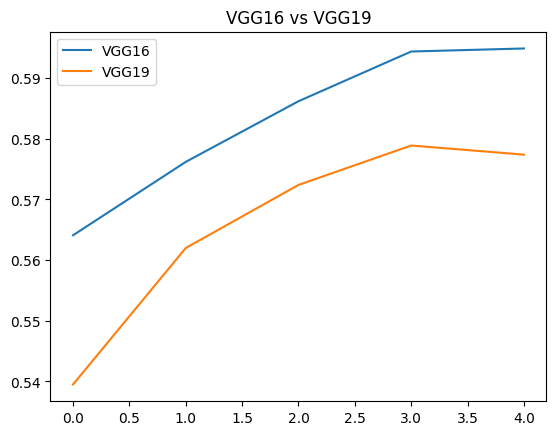

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vgg16.history['val_accuracy'], label='VGG16')
plt.plot(history_vgg19.history['val_accuracy'], label='VGG19')

plt.legend()
plt.title("VGG16 vs VGG19")
plt.show()

AUTOENCODER

Autoencoders learn compressed representations of images and can reconstruct them. This shows the model’s ability to capture essential features

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

input_img = Input(shape=(32,32,3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_train, X_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 120s 95ms/step - loss: 0.0091 - val_loss: 0.0060
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 146s 98ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 119s 95ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 94ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 121s 97ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 95ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 95ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 95ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 95ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 141s 94ms/step - loss: 0.0035 - val_loss: 0.0035


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


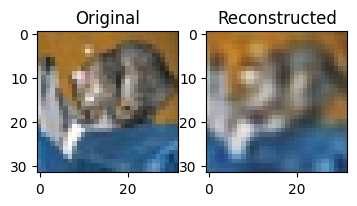

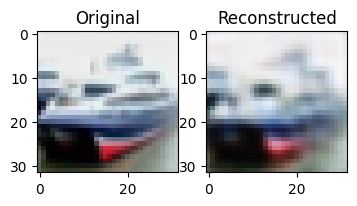

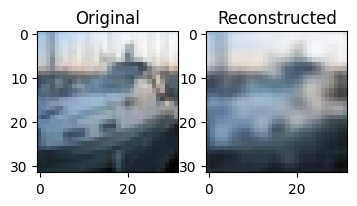

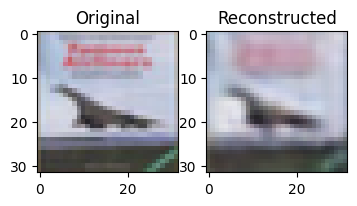

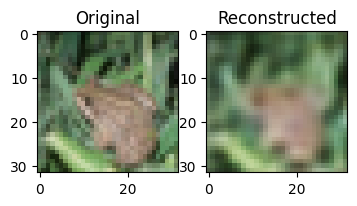

In [ ]:
decoded_imgs = autoencoder.predict(X_test[:5])

import matplotlib.pyplot as plt

for i in range(5):
    plt.figure(figsize=(4,2))

    # Original
    plt.subplot(1,2,1)
    plt.imshow(X_test[i])
    plt.title("Original")

    # Reconstructed
    plt.subplot(1,2,2)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")

    plt.show()

Can it remove noise?

DENOISING AUTOENCODER

STEP 1 ADD NOISE

In [ ]:
import numpy as np

noise_factor = 0.2

X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(size=X_test.shape)

# clip values
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

In [ ]:
autoencoder.fit(X_train_noisy, X_train,
                epochs=5,
                validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - loss: 0.0062 - val_loss: 0.0058
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 120s 96ms/step - loss: 0.0057 - val_loss: 0.0056
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 149s 102ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 134s 96ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 121s 97ms/step - loss: 0.0055 - val_loss: 0.0055


In [ ]:
decoded_imgs = autoencoder.predict(X_test_noisy[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


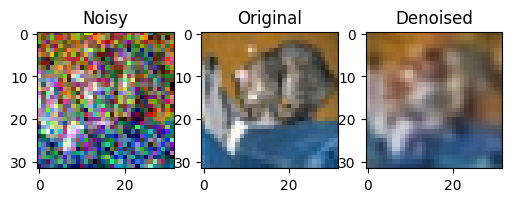

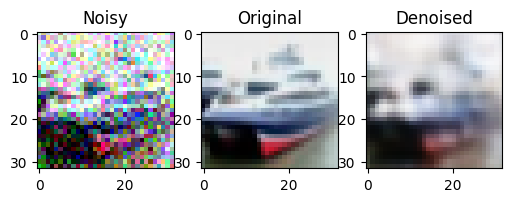

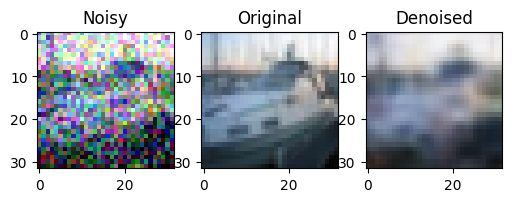

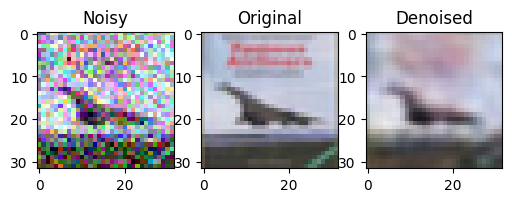

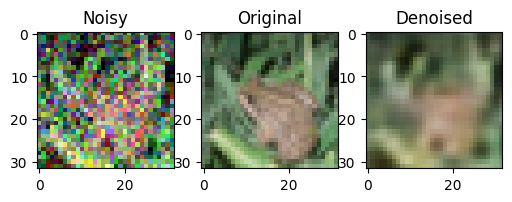

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.figure(figsize=(6,2))

    plt.subplot(1,3,1)
    plt.imshow(X_test_noisy[i])
    plt.title("Noisy")

    plt.subplot(1,3,2)
    plt.imshow(X_test[i])
    plt.title("Original")

    plt.subplot(1,3,3)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")

    plt.show()

The denoising autoencoder was able to remove noise from input images and reconstruct cleaner outputs. This demonstrates the model’s ability to learn robust feature representations

SPARSE AUTOENCODER

Sparse autoencoder enforces activation of only a few neurons, leading to efficient and meaningful feature learning. The reconstructed images retain important structures while ignoring less significant details

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.regularizers import l1

input_img = Input(shape=(32,32,3))


x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu',
           padding='same',
           activity_regularizer=l1(1e-5))(x)

encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

sparse_autoencoder = Model(input_img, decoded)

sparse_autoencoder.compile(optimizer='adam', loss='mse')

sparse_autoencoder.fit(X_train, X_train, epochs=10, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 125s 98ms/step - loss: 0.0226 - val_loss: 0.0126
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 95ms/step - loss: 0.0112 - val_loss: 0.0099
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 120s 96ms/step - loss: 0.0095 - val_loss: 0.0087
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 97ms/step - loss: 0.0086 - val_loss: 0.0080
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 143s 98ms/step - loss: 0.0079 - val_loss: 0.0075
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 94ms/step - loss: 0.0075 - val_loss: 0.0073
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 142s 94ms/step - loss: 0.0071 - val_loss: 0.0071
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 95ms/step - loss: 0.0069 - val_loss: 0.0068
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 145s 97ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 124s 99ms/step - loss: 0.0065 - val_loss: 0.0066


In [ ]:
decoded_imgs = sparse_autoencoder.predict(X_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [ ]:
model.fit(X_train, y_train, epochs=1, validation_split=0.2)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 775s 620ms/step - accuracy: 0.6152 - loss: 1.0945 - val_accuracy: 0.5858 - val_loss: 1.1799


In [ ]:

model.predict(X_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


array([[0.04201105, 0.1193451 , 0.01749563, 0.29499736, 0.1342092 ,
        0.08680946, 0.17803062, 0.02582064, 0.04435484, 0.056926  ]],
      dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


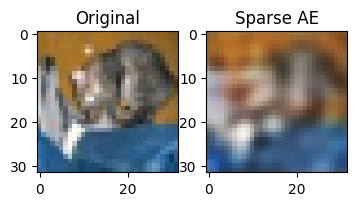

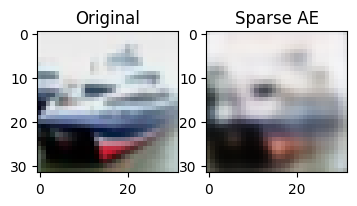

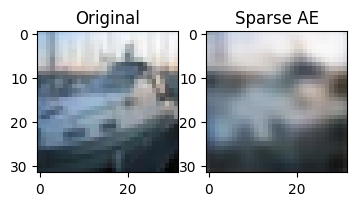

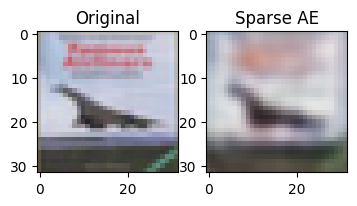

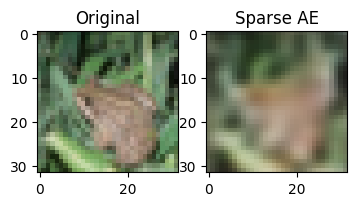

In [ ]:
decoded_imgs = sparse_autoencoder.predict(X_test[:5])

for i in range(5):
    plt.figure(figsize=(4,2))

    # Original
    plt.subplot(1,2,1)
    plt.imshow(X_test[i])
    plt.title("Original")

    # Sparse AE Output
    plt.subplot(1,2,2)
    plt.imshow(decoded_imgs[i])
    plt.title("Sparse AE")

    plt.show()

Image looks:


1.   Slightly more abstract
2.   Less detail
3.   Focus on important structure
